## Inverting a WalkTEM sounding using SimPEG

In this notebook, we walk through the process of using SimPEG to invert one of our WalkTEM soundings from A Mountain

In [15]:
## Libraries
# SimPEG functionality
import simpeg.electromagnetics.time_domain as tdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)

# discretize functionality
from discretize import TensorMesh

# Basic Python functionality
import os
import csv
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile

mpl.rcParams.update({"font.size": 14})

## Data

Data is taken from Station 4 of our measurements at A Mountain. All data points are averaged (similar to the stacked result)

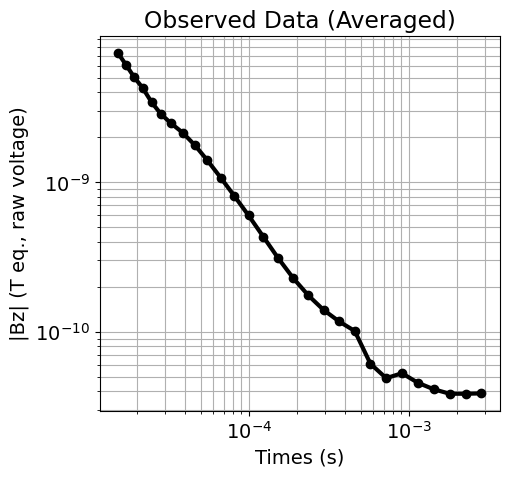

In [16]:
dobs = np.array([7.31936240e-09, 6.03026840e-09, 5.04393600e-09, 4.27605010e-09,
3.42702620e-09, 2.86103100e-09, 2.47212000e-09, 2.14011000e-09,
1.76022000e-09, 1.39656000e-09, 1.07387000e-09, 8.09564000e-10,
5.99197000e-10, 4.32414450e-10, 3.11999750e-10, 2.28925950e-10,
1.74885690e-10, 1.39798820e-10, 1.17135205e-10, 1.01132900e-10,
6.10766700e-11, 4.89264515e-11, 5.27987490e-11, 4.55880000e-11,
4.12470720e-11, 3.85240660e-11, 3.84829000e-11, 3.87217840e-11])

times = np.array([1.52000e-05, 1.72000e-05, 1.92000e-05, 2.17000e-05, 2.47000e-05, 2.82000e-05,
3.27000e-05, 3.87000e-05, 4.62000e-05, 5.52000e-05, 6.67000e-05, 8.12000e-05,
9.97000e-05, 1.23195e-04, 1.52195e-04, 1.89195e-04, 2.35695e-04, 2.93695e-04,
3.67195e-04, 4.59695e-04, 5.76195e-04, 7.22695e-04, 9.07195e-04, 1.13970e-03,
1.43219e-03, 1.80019e-03, 2.26370e-03, 2.84719e-03])


# Plot observed data
fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])
ax.loglog(times, np.abs(dobs), "k-o", lw=3)
ax.grid(which="both")
ax.set_xlabel("Times (s)")
ax.set_ylabel("|Bz| (T eq., raw voltage)")
ax.set_title("Observed Data (Averaged)")
plt.show()

## Defining the survey

In SimPEG, we define our source, receiver, waveform, and uncertainty levels, cmbining them into a data object. The uncertainty level can be tuned - but beware over and underfitting.

In [17]:
# Source geometry for a square loop with 40.0m side lengths and 0m height (on the ground).
source_vertices = np.array([
    [-40.0/2, -40.0/2, 0.0],
    [40.0/2, -40.0/2, 0.0],
    [40.0/2, 40.0/2, 0.0],
    [-40.0/2, 40.0/2, 0.0],
    [-40.0/2, -40.0/2, 0.0],
])

# Receiver geometry
receiver_location = np.array([0.0, 0.0, 0.0])  # or (N, 3) numpy.ndarray
receiver_orientation = "z"  # "x", "y" or "z"

# Receiver list
receiver_list = []
receiver_list.append(
    tdem.receivers.PointMagneticFluxDensity(
        receiver_location, times, orientation=receiver_orientation
    )
)

# Define the source waveform
waveform = tdem.sources.StepOffWaveform()

# Sources
source_list = [
    tdem.sources.LineCurrent(
        receiver_list=receiver_list,
        location=source_vertices,
        waveform=waveform,
    )
]

# Survey
survey = tdem.Survey(source_list)

# Define uncertainty levels - 10% (can be tuned)
uncertainties = 0.1 * np.abs(dobs)

print('Uncertainties: ')
print(uncertainties)

# Data object
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

Uncertainties: 
[7.31936240e-10 6.03026840e-10 5.04393600e-10 4.27605010e-10
 3.42702620e-10 2.86103100e-10 2.47212000e-10 2.14011000e-10
 1.76022000e-10 1.39656000e-10 1.07387000e-10 8.09564000e-11
 5.99197000e-11 4.32414450e-11 3.11999750e-11 2.28925950e-11
 1.74885690e-11 1.39798820e-11 1.17135205e-11 1.01132900e-11
 6.10766700e-12 4.89264515e-12 5.27987490e-12 4.55880000e-12
 4.12470720e-12 3.85240660e-12 3.84829000e-12 3.87217840e-12]


## Defining the Layers

We then define how many layers we want the subsurface to have and how large they will be. In this example, we start with a layer of 2 meters at the surface and make each layer 1.15 times larger than the last (2, 2.3, ...) until we reach a depth of 100m. Layers may need to be tuned for different sounding locations and set ups.

In [18]:
# Increase subsequent layers by the geometric factor until it reaches the maximum depth. 
# May need to be tuned to successfully run an inversion.

depth_min = 2.0  # top layer thickness
depth_max = 100.0  # depth to lowest layer
geometric_factor = 1.15  # rate of thickness increase

layer_thicknesses = [depth_min]
while np.sum(layer_thicknesses) < depth_max:
    layer_thicknesses.append(geometric_factor * layer_thicknesses[-1])

n_layers = len(layer_thicknesses) + 1  # Number of layers

print("Layer thicknesses: ")
print(layer_thicknesses)
print("Number of layers: ")
print(n_layers)

Layer thicknesses: 
[2.0, 2.3, 2.6449999999999996, 3.041749999999999, 3.498012499999999, 4.022714374999999, 4.626121531249998, 5.320039760937497, 6.1180457250781215, 7.035752583839839, 8.091115471415815, 9.304782792128186, 10.700500210947414, 12.305575242589525, 14.151411528977953, 16.274123258324643]
Number of layers: 
17


## Defining the Inversion

Next, we set up the initial conductivity/resistivity model, define the simulation, and update the inversion directives. Most of this is very complex, but luckily, can remain unchanged.

In [19]:
log_conductivity_map = maps.ExpMap(nP=n_layers)

# define a starting conductivity model (here we do 1/resistivity), converting to log-conductivity
starting_conductivity_model = np.log(1/5.0 * np.ones(n_layers))

# Reference model is the same format and starts the same
reference_conductivity_model = starting_conductivity_model.copy()

simulation_L2 = tdem.Simulation1DLayered(
    survey=survey, thicknesses=layer_thicknesses, sigmaMap=log_conductivity_map
)

# Test dpred at the starting model before running the inversion
try:
    dp_test = simulation_L2.dpred(starting_conductivity_model)
    if not np.all(np.isfinite(dp_test)):
        raise ValueError("dpred at starting model contains nan/inf")
    print("dpred (start) OK: min/max:", dp_test.min(), dp_test.max())
except Exception as e:
    print("Forward model failed at starting model:", e)
    # stop further unsafe inversion attempts
    raise

dmis_L2 = data_misfit.L2DataMisfit(simulation=simulation_L2, data=data_object)

# Define 1D cell widths
h = np.r_[layer_thicknesses, layer_thicknesses[-1]]
h = np.flipud(h)

# Create regularization mesh
regularization_mesh = TensorMesh([h], "N")

reg_L2 = regularization.WeightedLeastSquares(
    regularization_mesh,
    length_scale_x=10.0,
    reference_model=reference_conductivity_model,
    reference_model_in_smooth=False,
)

opt_L2 = optimization.InexactGaussNewton(
maxIter=50, maxIterLS=20, maxIterCG=20, tolCG=1e-3
)

inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)

update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list_L2 = [update_jacobi, starting_beta, beta_schedule, target_misfit]

# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

print("Starting conductivities: ")
print(starting_conductivity_model)

dpred (start) OK: min/max: 9.931847508838228e-12 1.1478185236374835e-08
Starting conductivities: 
[-1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791
 -1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791
 -1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791]


## Running the Inversion

Now we get to run the inversion! The output graph shows how well our inversion's model of predicted TDEM results aligns with our real TDEM results.


Running inversion with SimPEG v0.24.0

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver SolverLU and no solver_opts.***
                    
model has any nan: 0
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.46e+01  2.51e+03  0.00e+00  2.51e+03    3.88e+03      0              
   1  1.46e+01  4.25e+02  1.60e+01  6.60e+02    3.01e+02      0              
   2  1.46e+01  3.28e+02  2.00e+01  6.21e+02    2.42e+01      0   Skip BFGS  
   3  7.32e+00  3.35e+02  1.95e+01  4.78e+02    2.40e+02      0              
   4  7.32e+00  2.49e+02  2.79e+01  4.53e+02    2.13e+01      0              
   5  7.32e+00  2.53e+02  2.74e+01  4.53e+02    3.70e+00      0              
   6  3.66e+00  2.52e+

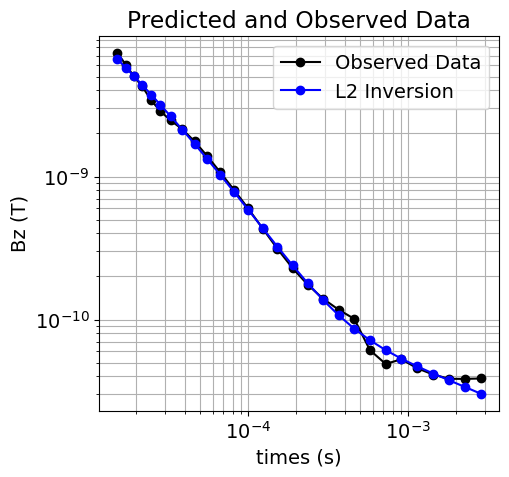

In [20]:
# Run the inversion
recovered_model_L2 = inv_L2.run(starting_conductivity_model)

dpred_L2 = simulation_L2.dpred(recovered_model_L2)

fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_axes([0.15, 0.15, 0.8, 0.75])
ax1.loglog(times, np.abs(dobs), "k-o")
ax1.loglog(times, np.abs(dpred_L2), "b-o")
ax1.grid(which="both")
ax1.set_xlabel("times (s)")
ax1.set_ylabel("Bz (T)")
ax1.set_title("Predicted and Observed Data")
ax1.legend(["Observed Data","L2 Inversion"], loc="upper right")
plt.show()

## Resistivity Model

Now, we can view the resistivity model that our inversion recovered. Note that SimPEG reports conductivity, so we take the inverse of these values before graphing them.

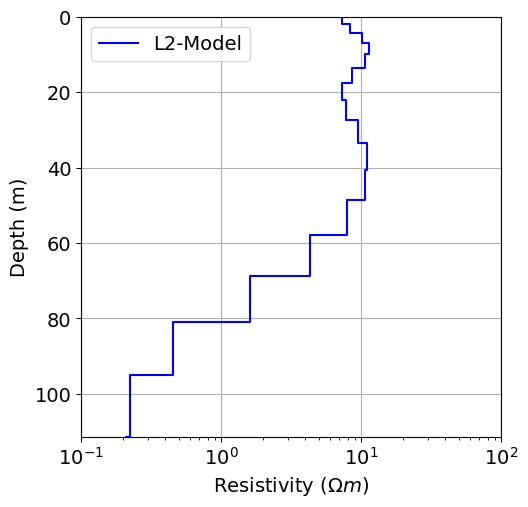

In [21]:
# Plot true model and recovered model
fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_axes([0.2, 0.15, 0.7, 0.7])
plot_1d_layer_model(
    layer_thicknesses, 1/(log_conductivity_map * recovered_model_L2), ax=ax1, color="b"
)
ax1.grid()
ax1.set_xlabel(r"Resistivity ($\Omega m$)")
ax1.set_xlim(0.1, 100)
ax1.set_ylim([np.sum(layer_thicknesses), 0])
ax1.legend(["L2-Model"])
plt.show()

## Notes

Many pieces of this process can be tweaked, and other inversion types (such as IRLS) are available. Different soundings may call for different inversion procedures.